# Notebook 02 — Feature Engineering
**Input:** `data/processed/delivery_orders_q1_2024.csv`
**Output:** `data/processed/train_features.csv`, `data/processed/test_features.csv`, `models/feature_pipeline.joblib`

Full simulated delivery orders dataset (~9.3M rows on the real run), built from `trips_weather_zones_q1_2024.csv` via `scripts/simulate_delivery_orders.py`. The notebook auto-detects sample vs full-dataset mode — see the load cell output.

Builds a model-ready feature matrix from raw delivery order data:
- Cyclical time encoding (hour, day-of-week)
- Weather flags and interaction features
- Target-encoded zone and borough columns
- Route-pair encoding
- Time-aware train/test split (no leakage)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings, os
warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
sns.set_theme(style='whitegrid')
print('Ready')


Ready


---
## 1. Load Delivery Orders


In [2]:
DATA_PATH = '../data/processed/delivery_orders_q1_2024.csv'

# Explicit dtypes keep memory in check on the full ~9M-row / ~1.1GB file —
# pandas' default type inference can use 3-4x the on-disk size in RAM.
DTYPES = {
    'pickup_zone': 'category', 'dropoff_zone': 'category',
    'pickup_borough': 'category', 'dropoff_borough': 'category',
    'temp': 'float32', 'prcp': 'float32', 'wspd': 'float32',
    'trip_distance': 'float32', 'base_travel_min': 'float32',
    'pickup_delay_min': 'float32', 'eta_min': 'float32',
}
df = pd.read_csv(DATA_PATH, parse_dates=['order_time'], dtype=DTYPES)

FULL_DATASET_EXPECTED_ROWS = 9_000_000   # approx. real Q1 2024 row count
is_sample = len(df) < FULL_DATASET_EXPECTED_ROWS * 0.5

print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'Columns: {list(df.columns)}')
print(f'ETA range: {df["eta_min"].min():.1f} – {df["eta_min"].max():.1f} min')
print(f'Date range: {df["order_time"].min()} → {df["order_time"].max()}')
print(f'Missing: {df.isnull().sum().to_dict()}')

if is_sample:
    print(f'\n⚠️  SAMPLE MODE: {len(df):,} rows loaded (~{FULL_DATASET_EXPECTED_ROWS:,} '
          f'expected in the full file). Feature encodings and model metrics below are '
          f'sample-based and will shift once trained on the full dataset.')
    n_hours = df['order_time'].dt.hour.nunique()
    n_days  = df['order_time'].dt.date.nunique()
    if n_hours < 24 or n_days < 30:
        print(f'    ⚠️  Limited coverage: {n_hours}/24 hours-of-day, {n_days} unique days.')
else:
    print(f'\n✓ FULL DATASET MODE: {len(df):,} rows — these are real Q1 2024 numbers.')
df.head(3)


Shape: (9286220, 13)
Memory: 464 MB
Columns: ['order_id', 'order_time', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough', 'temp', 'prcp', 'wspd', 'trip_distance', 'base_travel_min', 'pickup_delay_min', 'eta_min']
ETA range: 3.0 – 166.8 min
Date range: 2002-12-31 22:00:00 → 2024-04-01 00:00:00
Missing: {'order_id': 0, 'order_time': 0, 'pickup_zone': 28954, 'dropoff_zone': 41394, 'pickup_borough': 1568, 'dropoff_borough': 31916, 'temp': 0, 'prcp': 0, 'wspd': 0, 'trip_distance': 0, 'base_travel_min': 0, 'pickup_delay_min': 0, 'eta_min': 0}

✓ FULL DATASET MODE: 9,286,220 rows — these are real Q1 2024 numbers.


,order_id,order_time,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,temp,prcp,wspd,trip_distance,base_travel_min,pickup_delay_min,eta_min
0,0,2024-01-01,Penn Station/Madison Sq West,East Village,Manhattan,Manhattan,6.0,0.0,11.0,1.72,19.799999,6.275452,26.075451
1,1,2024-01-01,Lenox Hill East,Upper East Side North,Manhattan,Manhattan,6.0,0.0,11.0,1.80,6.600000,8.506037,15.106037
2,2,2024-01-01,Upper East Side North,East Village,Manhattan,Manhattan,6.0,0.0,11.0,4.70,17.916666,5.511647,23.428314


---
## 2. Temporal Features (Cyclical Encoding)
Hour 23 → hour 0 are adjacent. A linear `hour` integer doesn't capture this;
sin/cos encoding wraps around correctly.


In [3]:
df['hour']         = df['order_time'].dt.hour
df['day_of_week']  = df['order_time'].dt.dayofweek
df['month']        = df['order_time'].dt.month
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = df['hour'].isin([8,9,17,18,19]).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)
print('Temporal features added')
df[['hour','hour_sin','hour_cos','is_rush_hour','day_of_week','dow_sin','dow_cos']].head(3)


Temporal features added


,hour,hour_sin,hour_cos,is_rush_hour,day_of_week,dow_sin,dow_cos
0,0,0.0,1.0,0,0,0.0,1.0
1,0,0.0,1.0,0,0,0.0,1.0
2,0,0.0,1.0,0,0,0.0,1.0


---
## 3. Weather Features


In [4]:
df['is_rainy']    = (df['prcp'] > 0).astype(int)
df['is_windy']    = (df['wspd'] > 20).astype(int)
df['rain_x_dist'] = df['prcp'] * df['trip_distance']
df['wind_x_dist'] = df['wspd'] * df['trip_distance']
print(f'Rainy rows: {df["is_rainy"].sum():,}  ({df["is_rainy"].mean():.1%})')
print(f'Windy rows: {df["is_windy"].sum():,}  ({df["is_windy"].mean():.1%})')


Rainy rows: 1,476,780  (15.9%)
Windy rows: 1,103,981  (11.9%)


---
## 4. Time-Aware Train / Test Split
Sort by `order_time` and split 80/20. This mirrors production: the model always
trains on past data and predicts future orders.


In [5]:
df = df.sort_values('order_time').reset_index(drop=True)
split = int(len(df) * 0.8)
train_df = df.iloc[:split].copy()
test_df  = df.iloc[split:].copy()
print(f'Train: {len(train_df):,} rows  ({train_df["order_time"].min().date()} → {train_df["order_time"].max().date()})')
print(f'Test : {len(test_df):,}  rows  ({test_df["order_time"].min().date()} → {test_df["order_time"].max().date()})')


Train: 7,428,976 rows  (2002-12-31 → 2024-03-15)
Test : 1,857,244  rows  (2024-03-15 → 2024-04-01)


---
## 5. Target Encoding (zones, boroughs, routes)
Replace high-cardinality string columns with the mean `eta_min` per group,
calculated **on the training set only** to prevent data leakage.


In [8]:
global_mean = train_df['eta_min'].mean()

# Compute encodings from train only
pu_enc      = train_df.groupby('pickup_zone')['eta_min'].mean()
do_enc      = train_df.groupby('dropoff_zone')['eta_min'].mean()
borough_enc = train_df.groupby('pickup_borough')['eta_min'].mean()

# .astype(str) before fillna — pickup_zone/dropoff_zone load as 'category'
# dtype (for memory efficiency on the full ~9M-row file), and categoricals
# reject .fillna() with a value that isn't already a predefined category
# level. Casting to str first avoids that; route doesn't need to stay
# categorical since it's just a lookup key, not stored long-term.
train_df['route'] = (train_df['pickup_zone'].astype(str).fillna('UNK') + '|' +
                      train_df['dropoff_zone'].astype(str).fillna('UNK'))
test_df['route']  = (test_df['pickup_zone'].astype(str).fillna('UNK') + '|' +
                      test_df['dropoff_zone'].astype(str).fillna('UNK'))
route_enc   = train_df.groupby('route')['eta_min'].mean()

# Apply to both splits
for part in [train_df, test_df]:
    part['pu_zone_enc']    = part['pickup_zone'].map(pu_enc).astype(float).fillna(global_mean)
    part['do_zone_enc']    = part['dropoff_zone'].map(do_enc).astype(float).fillna(global_mean)
    part['pu_borough_enc'] = part['pickup_borough'].map(borough_enc).astype(float).fillna(global_mean)
    part['route_enc']      = part['route'].map(route_enc).astype(float).fillna(global_mean)

print(f'Global mean ETA: {global_mean:.2f} min')
print(f'Zone encodings computed on {len(pu_enc)} pickup zones, {len(do_enc)} dropoff zones')


Global mean ETA: 22.54 min
Zone encodings computed on 259 pickup zones, 259 dropoff zones


---
## 6. Final Feature Matrix


In [9]:
FEATURES = [
    'trip_distance',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month',
    'is_weekend', 'is_rush_hour',
    'temp', 'prcp', 'wspd',
    'is_rainy', 'is_windy',
    'rain_x_dist', 'wind_x_dist',
    'pu_zone_enc', 'do_zone_enc',
    'pu_borough_enc', 'route_enc',
]
TARGET = 'eta_min'

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Missing in X_train: {np.isnan(X_train).sum()}')
print(f'Missing in X_test : {np.isnan(X_test).sum()}')
print(f'y_train: mean={y_train.mean():.2f}  std={y_train.std():.2f}  min={y_train.min():.2f}  max={y_train.max():.2f}')


X_train: (7428976, 19)  |  X_test: (1857244, 19)
Missing in X_train: 0
Missing in X_test : 0
y_train: mean=22.54  std=13.64  min=3.00  max=162.54


---
## 7. Save Feature Files


In [12]:
train_out = train_df[FEATURES + [TARGET, 'order_time']]
test_out  = test_df[FEATURES  + [TARGET, 'order_time']]
train_out.to_csv('../data/processed/train_features.csv', index=False)
test_out.to_csv('../data/processed/test_features.csv',   index=False)
print(f'Saved train_features.csv — {len(train_out):,} rows')
print(f'Saved test_features.csv  — {len(test_out):,} rows')

meta = {
    'features':    FEATURES,
    'target':      TARGET,
    'global_mean': float(global_mean),
    'pu_enc':      pu_enc.to_dict(),
    'do_enc':      do_enc.to_dict(),
    'borough_enc': borough_enc.to_dict(),
    'route_enc':   route_enc.to_dict(),
}
joblib.dump(meta, '../models/feature_pipeline.joblib')
print('Saved models/feature_pipeline.joblib')


Saved train_features.csv — 7,428,976 rows
Saved test_features.csv  — 1,857,244 rows
Saved models/feature_pipeline.joblib


---
## 8. Feature Correlation with ETA


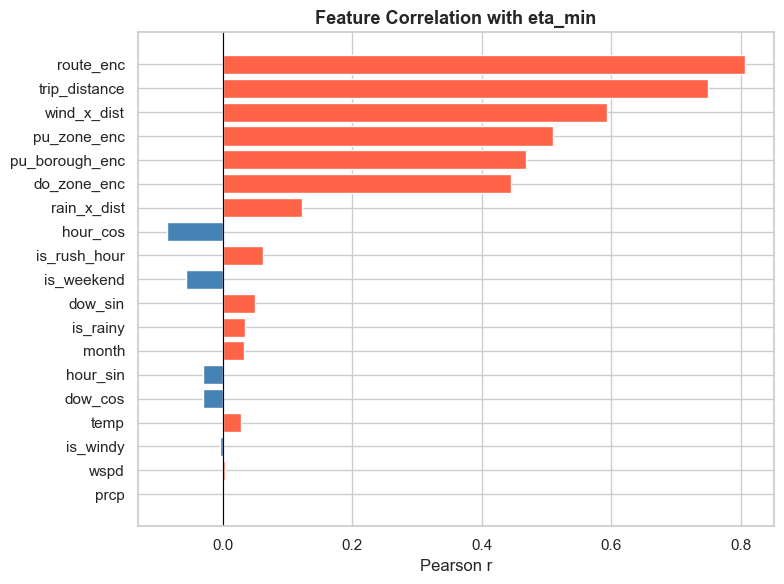

route_enc         0.807
trip_distance     0.749
wind_x_dist       0.594
pu_zone_enc       0.510
pu_borough_enc    0.469
do_zone_enc       0.446
rain_x_dist       0.122
hour_cos         -0.086
is_rush_hour      0.062
is_weekend       -0.057
dow_sin           0.050
is_rainy          0.035
month             0.033
hour_sin         -0.031
dow_cos          -0.030
temp              0.028
is_windy         -0.004
wspd              0.004
prcp              0.000


In [14]:
corr = pd.DataFrame(X_train, columns=FEATURES)
corr['eta_min'] = y_train
corr_vals = corr.corr()['eta_min'].drop('eta_min').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_vals.values]
plt.barh(corr_vals.index[::-1], corr_vals.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', lw=0.8)
plt.title('Feature Correlation with eta_min', fontsize=13, fontweight='bold')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.savefig('../data/processed/feature_correlation.png', bbox_inches='tight')
plt.show()
print(corr_vals.round(3).to_string())
